# Домашнее задание: KNN, линейная и логистическая регрессия

Сегодня вы сами построите несколько моделей и посмотрите, как меняется их поведение при разных параметрах.  
Цель — не просто “получить метрику”, а почувствовать, *как* ведут себя разные методы.

В заданиях будут:

1. **KNN-классификация** на данных со сложной геометрией.  
2. **KNN-регрессия** на синтетике с нелинейностями и локальными всплесками.  
3. **Линейная регрессия** — посмотрим на коэффициенты и сравним с KNN.  
4. **Логистическая регрессия** — компактная модель, удобно сравнивать с KNN.

Работа должна проходить автопроверку: в конце каждого блока есть assert’ы.


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from matplotlib.colors import ListedColormap

np.random.seed(42)


# 1. KNN-классификация: бинарные зашумлённые спирали

В этом задании мы будем работать с бинарной задачей классификации на данных,
которые не имеют линейной структуры — две переплетённые спирали с шумом.

Это один из классических сложных синтетических датасетов:
- линейные модели здесь работают плохо,  
- KNN даёт разумное качество, но сильно зависит от параметров,  
- правильные гиперпараметры нужно подбирать, иначе тестовая точность падает.

Ваша цель:
1. Сгенерировать бинарные спирали.  
2. Разбить данные на train/test.  
3. Визуализировать структуру.  
4. Перебрать параметры KNN (k, weights, p).  
5. Выбрать модель `knn_final`.  
6. Пройти автопроверку (порог будет установлен позже).


In [8]:
from matplotlib.colors import ListedColormap

def generate_two_spirals(n_points=1000, noise=1):
    """
    Генерация двух переплетённых спиралей с шумом.
    Эта задача бинарная.
    """
    n = n_points // 2

    # базовая спираль
    theta = np.sqrt(np.random.rand(n)) * 4 * np.pi
    r = 2 * theta + np.pi

    # класс 0
    x1 = r * np.cos(theta) + np.random.normal(0, noise, n)
    y1 = r * np.sin(theta) + np.random.normal(0, noise, n)

    # класс 1 — зеркальная спираль
    x2 = -r * np.cos(theta) + np.random.normal(0, noise, n)
    y2 = -r * np.sin(theta) + np.random.normal(0, noise, n)

    X = np.vstack([
        np.vstack([x1, y1]).T,
        np.vstack([x2, y2]).T
    ])

    y = np.hstack([
        np.zeros(n, dtype=int),
        np.ones(n, dtype=int)
    ])

    return X, y

X, y = generate_two_spirals(n_points=1200, noise=2)


## 1.3. Train/test split и визуализация данных

Разобьём выборку на обучение и тест.  
Вся настройка модели будет происходить по train,  
а тестовая точность будет использоваться для выбора лучшего KNN.


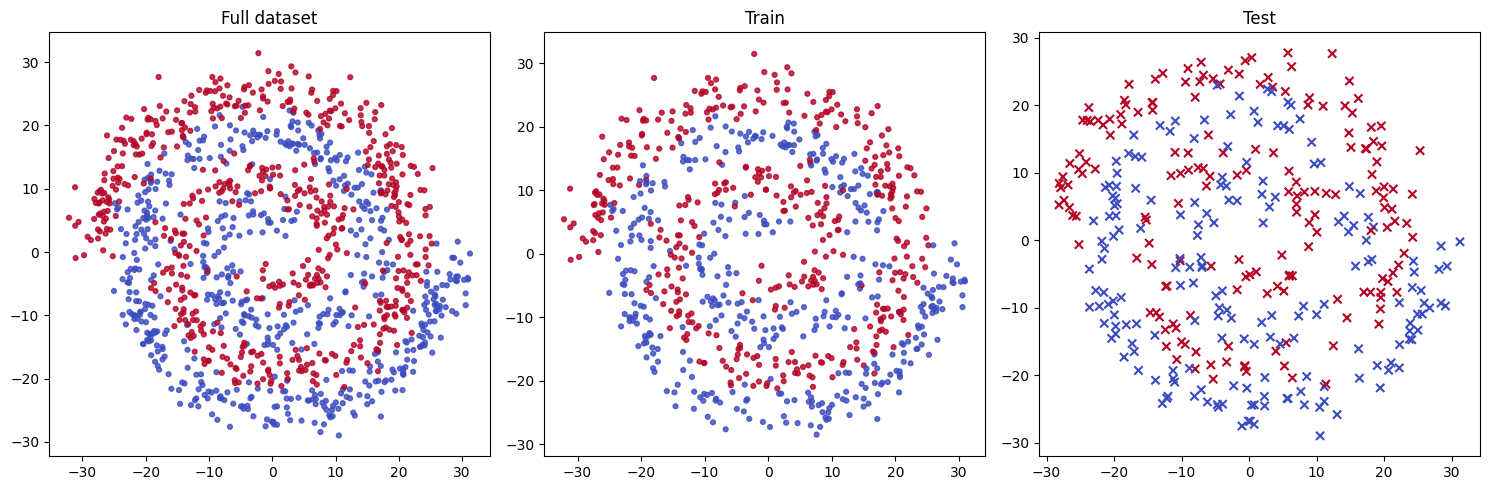

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Вся выборка
axes[0].scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=12, alpha=0.8)
axes[0].set_title("Full dataset")
axes[0].axis("equal")

# Только train
axes[1].scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="coolwarm", s=12, alpha=0.8)
axes[1].set_title("Train")
axes[1].axis("equal")

# 3. Только test
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, cmap="coolwarm", s=35, marker="x")
axes[2].set_title("Test")
axes[2].axis("equal")

plt.tight_layout()
plt.show()


## Исследование гиперпараметров KNN

Задача простая: есть выборка, нужно получить максимально возможную точность на тесте. Обучаем модель только на трейне.

Что стоит перебрать:
- число соседей: 1, 3, 5, 10, 20, 30, 50  
- равномерные веса / весовые схемы
- разные метрики расстояния (евклидовая / манхэттенская)

Ориентируемся на **test accuracy**

## Пример: перебор k в цикле

Ниже — простой пример, как можно перебрать несколько значений k в цикле и посмотреть, что происходит с качеством на трейне и тесте.

Это только демонстрация подбора одного гиперпараметра.  
В следующей ячейке вам нужно будет расширить перебор и добавить туда веса и метрики расстояния.


In [10]:
ks = [1, 3, 5, 10, 17, 18, 19, 20, 21, 22, 30]
wgths = ['uniform', 'distance']
results = []

for k in ks:
    model = KNeighborsClassifier(
        n_neighbors=k, weights=w
    )
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, model.predict(X_test))
    
    results.append((k, train_acc, test_acc))
    
    print(f"k={k:2d} | train={train_acc:.3f} | test={test_acc:.3f}")


NameError: name 'w' is not defined

In [11]:
# TODO:
# Переберите разные варианты K - от 1 до примерно 50.
# Веса выбирайте на своё усмотрение (uniform / distance или другие из документации).
# Метрики расстояния — тоже на ваше усмотрение. Загляните в доки KNeighborsClassifier.
#
# Для каждой конфигурации посчитайте качество на трейне и на тесте.
#
# Все результаты сложите в список results.
# Формат одного элемента: (k, weights, p, train_acc, test_acc)
#
# В конце заполните следующие переменные:

results=[]
weights = ['uniform', 'distance']
max_acc = 0.1
for w in weights:
        for p in range(1, 2):
            for k in range(1, 50, 1):
                model = KNeighborsClassifier(
                    n_neighbors = k, weights = w, p = p
                )
                model.fit(X_train, y_train)
    
                train_acc = accuracy_score(y_train, model.predict(X_train))
                test_acc = accuracy_score(y_test, model.predict(X_test))
    
                if max_acc < test_acc:
                    max_acc = test_acc
                if test_acc > 0.9:
                    print(f"w={w} | p={p} | k={k:2d} | train={train_acc:.3f} | test={test_acc:.3f}")
    
                results.append((k, w, p, train_acc, test_acc))

            
print(max_acc)
# results         = [...]  # общий список со всеми результатами
best_model      = KNeighborsClassifier(n_neighbors=18)   # лучшая модель

bk, bw, bp, train_acc, test_acc = results[11]

best_params = {
    'n_neighbors': bk,
    'weights': bw,
    'p': bp
}  # словарь с параметрами лучшей модели
best_train_acc  = 0.9226190476190477   # train accuracy лучшей модели
best_test_acc   = max_acc   # test accuracy лучшей модели
best_params

w=uniform | p=1 | k=12 | train=0.923 | test=0.908
w=uniform | p=1 | k=14 | train=0.921 | test=0.908
w=uniform | p=1 | k=16 | train=0.919 | test=0.903
w=uniform | p=1 | k=20 | train=0.918 | test=0.903
0.9083333333333333


{'n_neighbors': 12, 'weights': 'uniform', 'p': 1}

In [12]:
assert all(v in globals() for v in [
    "results", "best_model", "best_params",
    "best_train_acc", "best_test_acc"
])

assert isinstance(results, list) and len(results) > 0
assert all(len(r) == 5 for r in results)

assert isinstance(best_params, dict)
assert 0 <= best_train_acc <= 1 and 0 <= best_test_acc <= 1

assert best_test_acc >= 0.908, f"Слабое качество: {best_test_acc:.3f}. Попробуйте другие параметры."


In [13]:
# TODO:

# Превратите список results в DataFrame.
# Названия колонок: ["k", "weights", "p", "train_acc", "test_acc"]
# Отсортируйте по test_acc по убыванию.
#
df_results = pd.DataFrame(
    [{"k": k, "weights" : w, "p" : p, "train_acc" : train_acc, "test_acc" : test_acc} for k, w, p, train_acc, test_acc in results],
    columns=["k", "weights", "p", "train_acc", "test_acc"]
)
df_results["test_acc"].sort_values(ascending=False)

13    0.908333
11    0.908333
15    0.902778
19    0.902778
22    0.900000
        ...   
43    0.838889
45    0.825000
48    0.822222
46    0.822222
47    0.813889
Name: test_acc, Length: 98, dtype: float64

In [14]:
# TODO:
# Обучите итоговую модель KNN с лучшими найденными параметрами.

# Далее:
# - сделайте предсказания на трейне и тесте,
# - посчитайте Accuracy, Precision и Recall,
# - сохраните всё в переменные.


best_final_model = KNeighborsClassifier(
    n_neighbors = 12, weights = 'uniform', p = 1
)
best_final_model.fit(X_train, y_train)

train_acc = accuracy_score(y_train, best_final_model.predict(X_train))
train_prec = precision_score(y_train, best_final_model.predict(X_train))
train_rec = recall_score(y_train, best_final_model.predict(X_train))

test_acc = accuracy_score(y_test, best_final_model.predict(X_test))
test_prec = precision_score(y_test, best_final_model.predict(X_test))
test_rec = recall_score(y_test, best_final_model.predict(X_test))
test_acc

0.9083333333333333

In [16]:
# Проверка итоговой модели KNN

required_vars = [
    "best_final_model",
    "train_acc", "train_prec", "train_rec",
    "test_acc", "test_prec", "test_rec"
]

assert all(v in globals() for v in required_vars)

assert 0 <= train_acc <= 1 and 0 <= test_acc <= 1
assert 0 <= train_prec <= 1 and 0 <= test_prec <= 1
assert 0 <= train_rec <= 1 and 0 <= test_rec <= 1

assert test_acc  >= 0.908, f"test_acc слабый: {test_acc:.3f}. Попробуйте другие параметры."
assert test_prec >= 0.890,  f"test_prec слабый: {test_prec:.3f}. Модель требует улучшения."
assert test_rec  >= 0.890, f"test_rec слабый: {test_rec:.3f}. Модель недообучена."


## Визуализация результата

Теперь посмотрим на картинку целиком.  
Слева — как выглядит решение KNN из коробки с настройками по умолчанию.  
Справа — модель с подобранными гиперпараметрами, которую вы получили выше


In [17]:
x_min, x_max = X[:,0].min() - .5, X[:,0].max() + .5
y_min, y_max = X[:,1].min() - .5, X[:,1].max() + .5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 600),
    np.linspace(y_min, y_max, 600)
)

# Baseline KNN
default_knn = KNeighborsClassifier()
default_knn.fit(X_train, y_train)

Z_default = default_knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

train_pred_def = default_knn.predict(X_train)
test_pred_def  = default_knn.predict(X_test)

train_acc_def  = accuracy_score(y_train, train_pred_def)
test_acc_def   = accuracy_score(y_test,  test_pred_def)

# Best KNN
Z_best = best_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Рисуем:

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].contourf(
    xx, yy, Z_default,
    cmap=ListedColormap(["#AAAAFF", "#FFAAAA"]),
    alpha=0.28
)

axes[0].scatter(
    X_train[:,0], X_train[:,1],
    c=y_train, cmap="coolwarm",
    s=12, alpha=0.6, label="train"
)

axes[0].scatter(
    X_test[:,0], X_test[:,1],
    c=y_test, cmap="coolwarm",
    s=35, marker="x", label="test"
)

axes[0].set_title(
    f"Default KNN\n"
    f"train={train_acc_def:.3f}, test={test_acc_def:.3f}"
)

axes[0].axis("equal")
axes[0].legend()

axes[1].contourf(
    xx, yy, Z_best,
    cmap=ListedColormap(["#AAAAFF", "#FFAAAA"]),
    alpha=0.28
)

axes[1].scatter(
    X_train[:,0], X_train[:,1],
    c=y_train, cmap="coolwarm",
    s=12, alpha=0.6, label="train"
)

axes[1].scatter(
    X_test[:,0], X_test[:,1],
    c=y_test, cmap="coolwarm",
    s=35, marker="x", label="test"
)

axes[1].set_title(
    f"Best KNN\n"
    f"k={best_params['n_neighbors']}, "
    f"weights={best_params['weights']}, "
    f"p={best_params['p']}\n"
    f"train={best_train_acc:.3f}, test={best_test_acc:.3f}"
)

axes[1].axis("equal")
axes[1].legend()

plt.tight_layout()
plt.show()


NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## Линейная регрессия на Ames Housing: работа с реальными пропусками

В этом блоке мы используем датасет Ames Housing.  
Задача: предсказать стоимость дома (`SalePrice`).

Особенности датасета:
- много числовых и категориальных признаков;
- пропуски встречаются естественным образом;
- качество модели напрямую зависит от корректной предобработки.

Что нужно сделать:
1. загрузить данные;
2. исследовать пропуски;
3. подготовить предобработку для числовых и категориальных признаков;
4. обучить линейную регрессию;
5. вычислить метрики качества: **MSE и MAE**;
6. пройти автоматическую проверку через ассерт-блок.


In [39]:
# TODO:

# 1. Загрузите датасет AmesHousing.csv с платформы edu (из раздела с ДЗ) и подгрузите его локально в colab.
#
# 2. Выведите head(), info().
# 3. Посчитайте количество пропусков в каждом признаке.
# 4. Разделите признаки на числовые и категориальные.
#
# Требуется сохранить:
# df, numerical_cols, categorical_cols

df = pd.read_csv('ameshousing.csv')

#numerical_cols = [col for col in df.columns if df[col].dtype == 'int64' or df[col].dtype == 'float64']
numerical_cols = df.select_dtypes(include='number').columns.tolist()
#categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_cols

['MS Zoning',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin Type 2',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 'Kitchen Qual',
 'Functional',
 'Fireplace Qu',
 'Garage Type',
 'Garage Finish',
 'Garage Qual',
 'Garage Cond',
 'Paved Drive',
 'Pool QC',
 'Fence',
 'Misc Feature',
 'Sale Type',
 'Sale Condition']

In [40]:
assert "df" in globals()
assert df.shape[0] > 500
assert df.isna().sum().sum() > 0, "Пропусков не обнаружено — проверьте загрузку датасета."

assert "numerical_cols" in globals() and len(numerical_cols) > 0
assert "categorical_cols" in globals() and len(categorical_cols) > 0


In [41]:
# Разобьём данные на train и test

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df.drop("SalePrice", axis=1),
    df["SalePrice"],
    test_size=0.2,
    random_state=42
)


In [26]:
X_train_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2344 entries, 381 to 860
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2344 non-null   int64  
 1   PID              2344 non-null   int64  
 2   MS SubClass      2344 non-null   int64  
 3   MS Zoning        2344 non-null   object 
 4   Lot Frontage     1951 non-null   float64
 5   Lot Area         2344 non-null   int64  
 6   Street           2344 non-null   object 
 7   Alley            162 non-null    object 
 8   Lot Shape        2344 non-null   object 
 9   Land Contour     2344 non-null   object 
 10  Utilities        2344 non-null   object 
 11  Lot Config       2344 non-null   object 
 12  Land Slope       2344 non-null   object 
 13  Neighborhood     2344 non-null   object 
 14  Condition 1      2344 non-null   object 
 15  Condition 2      2344 non-null   object 
 16  Bldg Type        2344 non-null   object 
 17  House Style      2

## Обработка вещественных признаков

Вещественные признаки требуют двух шагов:

1. **Заполнение пропусков.**  
   Пропуски заполняем медианой, вычисленной **только на обучающей выборке**.  
   Медиана устойчива к выбросам и даёт стабильный результат.

2. **Масштабирование.**  
   Используем `StandardScaler`.  
   Важно:  
   - на **обучающей выборке** вызываем `fit_transform`,  
   - на **тестовой выборке** — только `transform` тем же самым скейлером.  
   Иначе получается утечка информации из теста в обучение.

На выходе получаем два объекта:
- **X_train_num_processed** — обработанные числовые признаки для train,
- **X_test_num_processed** — обработанные числовые признаки для test.


In [42]:
# TODO:

# 1. Выделить вщественные признаки из X_train_raw и X_test_raw по numerical_cols
# 2. Заполнить пропуски медианой, вычисленной на train
# 3. Обучить StandardScaler на обучающих данных (fit),
#    применить тот же scaler к тестовым (transform).

# На выходе должны получиться два объекта:
#   X_train_num_processed — числовые признаки train после заполнения пропусков и масштабирования
#   X_test_num_processed  — те же преобразования, применённые к test
numerical_cols = X_train_raw.select_dtypes(include='number').columns.tolist()

# 3. Считаем медианы на train
train_medians = X_train_raw[numerical_cols].median()

# 4. Заполняем пропуски
X_train_num = X_train_raw[numerical_cols].fillna(train_medians)
X_test_num  = X_test_raw[numerical_cols].fillna(train_medians)

# 5. Масштабирование
scaler_num = StandardScaler()
scaler_num.fit(X_train_num)

X_train_num_processed = pd.DataFrame(scaler_num.transform(X_train_num), columns=numerical_cols, index=X_train_num.index)
X_test_num_processed  = pd.DataFrame(scaler_num.transform(X_test_num), columns=numerical_cols, index=X_test_num.index)


In [44]:
assert "X_train_num_processed" in globals(), "Нет train-таблицы с числовыми признаками."
assert "X_test_num_processed" in globals(), "Нет test-таблицы с числовыми признаками."
assert "scaler_num" in globals(), "Скейлер не создан."

# пропусков быть не должно
assert X_train_num_processed.isna().sum().sum() == 0, "В train числовых признаках остались пропуски."
assert X_test_num_processed.isna().sum().sum() == 0, "В test числовых признаках остались пропуски."

# размерности должны совпадать
assert X_train_num_processed.shape[1] == len(numerical_cols), "Неверное количество числовых признаков."
assert X_test_num_processed.shape[1] == len(numerical_cols), "Неверное количество числовых признаков."



## Обработка категориальных признаков

Категориальные признаки также обрабатываем в два шага:

1. **Заполнение пропусков.**  
   Для каждого категориального столбца берём самое частое значение (mode),
   вычисленное **только на обучающей выборке**, и заполняем пропуски в train и test.

2. **One-Hot-Encoding.**  
   Кодируем признаки через `pd.get_dummies(drop_first=True)`.  
   Важно: OHE обучается **только на train**,  
   а для test мы приводим столбцы к той же структуре (`reindex`), заполняя отсутствующие категории нулями.

На выходе должны появиться два объекта:
- **X_train_cat_processed** — закодированные категориальные признаки для train,  
- **X_test_cat_processed** — такие же признаки для test, со строго совпадающими столбцами.


In [52]:
# TODO:
# 1. Выделить категориальные признаки из X_train_raw и X_test_raw по categorical_cols.
# 2. Заполнить пропуски самым частым значением (mode), вычисленным на обучающей выборке.
# 3. Применить One-Hot-Encoding:
#       - обучить кодирование (get_dummies) на train,
#       - привести test к тем же столбцам через reindex.
#
# На выходе должны появиться два объекта:
#   X_train_cat_processed — категориальные признаки (train) после заполнения пропусков и OHE.
#   X_test_cat_processed  — категориальные признаки (test) после тех же преобразований.

mode = X_train_raw[categorical_cols].mode()

X_train_raw[categorical_cols] = X_train_raw[categorical_cols].fillna(mode)
X_test_raw[categorical_cols] = X_test_raw[categorical_cols].fillna(mode)

ohe_train = pd.get_dummies(X_train_raw[categorical_cols], drop_first = True)
ohe_test = pd.get_dummies(X_test_raw[categorical_cols], drop_first = True)

X_train_cat_processed = ohe_train
X_test_cat_processed = ohe_test.reindex(columns=ohe_train.columns, fill_value=0)

In [53]:
assert "X_train_cat_processed" in globals(), "Нет train-таблицы категориальных признаков."
assert "X_test_cat_processed" in globals(), "Нет test-таблицы категориальных признаков."

# пропусков быть не должно
assert X_train_cat_processed.isna().sum().sum() == 0, "В train категориальных признаках остались пропуски."
assert X_test_cat_processed.isna().sum().sum() == 0, "В test категориальных признаках остались пропуски."

# столбцы train и test должны совпадать
assert list(X_train_cat_processed.columns) == list(X_test_cat_processed.columns), \
    "Столбцы train/test для категориальных признаков не совпадают."


## Сборка итоговых обучающих матриц

Теперь объединим обработанные числовые и категориальные признаки для train и test.

У нас уже есть:
- **X_train_num_processed**, **X_test_num_processed** — числовые признаки,
- **X_train_cat_processed**, **X_test_cat_processed** — категориальные признаки.

Объединяем их с помощью `pd.concat(axis=1)` — сначала для train, потом для test.

Целевая переменная:
- `y_train` и `y_test` мы уже получили при разбиении данных.

Итоговые объекты:
- **X_train** — финальная обучающая матрица,
- **X_test** — финальная тестовая матрица.


In [55]:
# TODO:
# Собрать итоговые матрицы признаков для train и test, объединив:
#   - X_train_num_processed + X_train_cat_processed
#   - X_test_num_processed  + X_test_cat_processed
#
# Используем pd.concat(axis=1).
#
# На выходе должны получиться:
#   X_train — финальная обучающая матрица
#   X_test  — финальная тестовая матрица

X_train = pd.concat([X_train_num_processed, X_train_cat_processed], axis=1)
X_test = pd.concat([X_test_num_processed, X_test_cat_processed], axis=1)

In [57]:
assert "X_train" in globals(), "X_train не создан."
assert "X_test" in globals(), "X_test не создан."

assert X_train.isna().sum().sum() == 0, "В X_train остались пропуски."
assert X_test.isna().sum().sum() == 0, "В X_test остались пропуски."

assert X_train.shape[1] == X_test.shape[1], "Число признаков в train и test не совпадает."

assert X_train.shape[0] == len(y_train), "Размер X_train не совпадает с y_train."
assert X_test.shape[0] == len(y_test), "Размер X_test не совпадает с y_test."

## Обучение линейной регрессии

Теперь обучим базовую линейную регрессию на предобработанных данных.

У нас уже есть:
- **X_train**, **X_test** — собранные матрицы признаков,
- **y_train**, **y_test** — целевая переменная.

Шаги:
1. Обучаем модель `LinearRegression` на тренировочных данных
2. Получаем предсказания для train и test
3. Считаем две метрики качества:
   - **MSE** — среднеквадратичная ошибка,
   - **MAE** — абсолютная ошибка.
4. Сохраняем результаты в отдельные переменные.

Важно:
- убедиться, что размеры X и y совпадают,
- модель обучается только на предобработанных данных.


In [59]:
# TODO:
# 1. Создать и обучить модель LinearRegression на X_train, y_train.
# 2. Получить предсказания для train и test.
# 3. Посчитать MSE и MAE для обеих выборок.
#
# Требуется сохранить переменные:
#   model
#   y_train_pred
#   y_test_pred
#   train_mse, test_mse
#   train_mae, test_mae
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


In [60]:
required = [
    "model", "y_train_pred", "y_test_pred",
    "train_mse", "test_mse",
    "train_mae", "test_mae"
]

assert all(v in globals() for v in required), "Не все обязательные переменные созданы."

assert len(y_train_pred) == len(y_train), "Размер y_train_pred не совпадает с y_train."
assert len(y_test_pred)  == len(y_test),  "Размер y_test_pred не совпадает с y_test."


## Регуляризация и подбор гиперпараметров для линейной модели

Обычная линейная регрессия старается подобрать такие веса, которые лучше всего объясняют данные.
Если признаков много, есть шум или сильные зависимости между признаками, веса могут становиться слишком большими.
Такая модель часто переобучается: на тренировочных данных работает отлично, на новых — хуже.

Чтобы стабилизировать модель, используют **регуляризацию** — штраф за большие коэффициенты.

Сосредоточимся на **Ridge (L2)**:
- Ridge сглаживает веса и делает их меньше.
- Параметр **alpha** управляет силой штрафа:
  - маленькая alpha - почти обычная линейная регрессия,
  - большая alpha - модель сильнее «сжимает» веса.

Lasso (L1) работает похожим образом, но может занулять признаки.  
По аналогии можно применять те же шаги, но здесь разбираем только Ridge.

---

## GridSearch: перебираем alpha автоматически

Вместо ручного перебора используем **GridSearchCV**.

GridSearch делает две вещи:
1. перебирает заданные значения alpha,
2. оценивает качество модели на нескольких разбиениях данных и выбирает лучший вариант.

В этом блоке нам нужно:
1. задать сетку значений alpha,
2. запустить GridSearch для Ridge,
3. посмотреть, как меняется MAE при разных alpha,
4. выбрать лучшую модель и сохранить её параметры.


In [68]:
# TODO:
# 1. Задать сетку значений alpha (например, логарифмическую).
# 2. Настроить GridSearch для Ridge-регрессии.
# 3. Обучить перебор на тренировочных данных.
# 4. Достать MAE для каждого значения alpha.

# Требуется сохранить:
#   alphas     — список значений alpha
#   grid_ridge — объект GridSearchCV после обучения
#   ridge_mae  — список ошибок MAE для всех alpha

# Да-да, разобраться в том как это делать предлагается вам, на практике разбираться в новых либах придётся часто!
# Доку по GridSearchCV можно посмотреть тут: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)


alphas = np.arange(0.1, 10, 0.1)
grid_ridge = GridSearchCV(
    estimator=model,
    param_grid={'alpha' : alphas}
)

grid_ridge.fit(X_train, y_train)
ridge_mae = grid_ridge.cv_results_['mean_test_score']

In [69]:
required = ["alphas", "grid_ridge", "ridge_mae"]
assert all(v in globals() for v in required), "Некоторые переменные не созданы."

assert len(alphas) == len(ridge_mae), "Число значений alpha и MAE должно совпадать."
assert isinstance(ridge_mae, np.ndarray) or isinstance(ridge_mae, list), "ridge_mae должно быть массивом или списком."


In [70]:
# Давайте посмотрим, что получилось после перебора alpha.

best_alpha = grid_ridge.best_params_["alpha"]
best_model = Ridge(alpha=best_alpha)

best_model.fit(X_train, y_train)
best_coef = best_model.coef_

best_alpha, best_model


(7.5, Ridge(alpha=7.5))

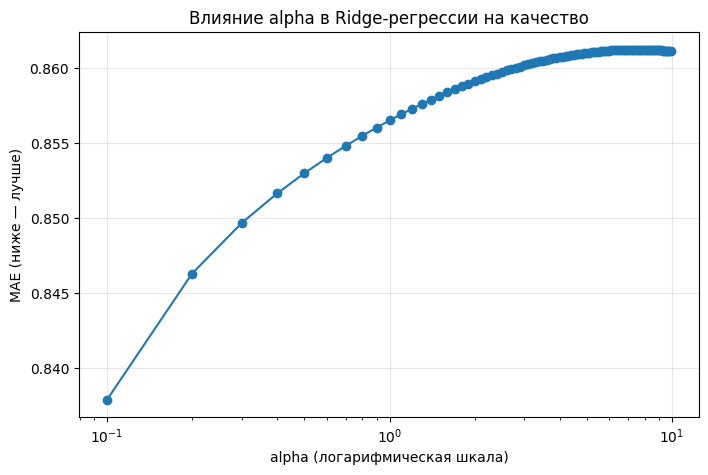

In [71]:
plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_mae, marker="o")
plt.xscale("log")
plt.xlabel("alpha (логарифмическая шкала)")
plt.ylabel("MAE (ниже — лучше)")
plt.title("Влияние alpha в Ridge-регрессии на качество")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# TODO:
# Достать коэффициенты финальной Ridge-модели и визуализировать их.
#
# Что сделать:
# 1. Взять веса модели через .coef_.
# 2. Соотнести каждый вес с именем признака.
# 3. Отсортировать признаки по абсолютному значению коэффициента.
# 4. Построить небольшую визуализацию (например, топ-20 признаков)

w = model.coef_

In [72]:
# Посмотрим что у нас получилось по итогу:

# Baseline
base = LinearRegression().fit(X_train, y_train)
base_test_pred = base.predict(X_test)
base_mae  = mean_absolute_error(y_test, base_test_pred)
base_rmse = np.sqrt(mean_squared_error(y_test, base_test_pred))

# Ridge с лучшим alpha
best_alpha = grid_ridge.best_params_["alpha"]
ridge = Ridge(alpha=best_alpha).fit(X_train, y_train)
ridge_test_pred = ridge.predict(X_test)
ridge_mae  = mean_absolute_error(y_test, ridge_test_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

# Улучшение
mae_gain  = 100 * (base_mae  - ridge_mae)  / base_mae
rmse_gain = 100 * (base_rmse - ridge_rmse) / base_rmse

print("=== Качество моделей (test) ===")
print(f"LinearRegression: MAE={base_mae:,.0f},  RMSE={base_rmse:,.0f}")
print(f"Ridge (alpha={best_alpha}): MAE={ridge_mae:,.0f},  RMSE={ridge_rmse:,.0f}")

print("\n=== Улучшение Ridge ===")
print(f"MAE  улучшилось на {mae_gain:.1f}%")
print(f"RMSE улучшилось на {rmse_gain:.1f}%")


=== Качество моделей (test) ===
LinearRegression: MAE=618,361,  RMSE=620,710
Ridge (alpha=7.5): MAE=18,024,  RMSE=30,460

=== Улучшение Ridge ===
MAE  улучшилось на 97.1%
RMSE улучшилось на 95.1%


## Итоги

Если вы дошли до этого места — вы проделали довольно большой путь
Вы руками собрали весь ML-пайплайн: от сырых данных до оцененных моделей

Что вы сделали в этой домашке:
- разобрали числовые и категориальные признаки, аккуратно обработали пропуски;
- разделили fit / transform между train и test так, как это делается в реальных проектах;
- обучили KNN и посмотрели, как он ведёт себя на данных;
- обучили линейную регрессию, оценили её качество;
- подобрали `alpha` для Ridge и убедились, что регуляризация делает модель стабильнее;
- посмотрели на коэффициенты модели

В рабочей разработке МЛ алгоритмов всё это обычно упаковывают в **Pipeline** — он умеет объединять предобработку, кодирование, масштабирование, обучение и подбор параметров в одном объекте.  
Сегодня мы делали всё вручную, чтобы вы почувствовали механику.  
В следующей домашке или воркшопе уже познакомимся с Pipeline и упростим жизнь.

Если вы это сделали - вы уже можете честно сказать, что умеете обучать простые модели.  
Добро пожаловать в машин лёрнеры :)
